In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
np.random.seed(42)
data = {
    "OrderID" : range(1,101),
    "Product": np.random.choice(["Laptop","Mouse","Keyboard","Monitor",None] ,100),
    "Quantity":np.random.randint(1,20,100),
    "Price":np.random.uniform(10,500,100).round(2),
    "Region":np.random.choice(["North","South","East","West"],100)

}
df = pd.DataFrame(data)
df.loc[5:8,"Price"] = np.nan
df = pd.concat([df,df.iloc[0:3]],ignore_index=True)

df.to_csv("sample_sales.csv",index=False)
df.head()


,OrderID,Product,Quantity,Price,Region
0,1,Monitor,7,18.13,East
1,2,None,9,260.93,South
2,3,Keyboard,8,120.98,North
3,4,None,12,326.13,West
4,5,None,2,95.44,North


In [3]:
print("shape:",df.shape)
print("\nData Types\n",df.dtypes )
print("\n Missing Values\n",df.isnull().sum())
print("\n Dublicates:\n",df.duplicated().sum())

shape: (103, 5)

Data Types
 OrderID       int64
Product      object
Quantity      int32
Price       float64
Region       object
dtype: object

 Missing Values
 OrderID      0
Product     20
Quantity     0
Price        4
Region       0
dtype: int64

 Dublicates:
 3


In [4]:
def clean_data(df):
    df= df.copy()
    
    before = df.shape[0]
    df = df.drop_duplicates()
    after = df.shape[0]
    print(f"removed{before  - after} Duplicate row")

    numeric_column = df.select_dtypes(include=[np.number]).columns
    for col in numeric_column:
        if df[col].isnull().sum() >0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"fill mising values{col} with median:{median_val}")


    text_column = df.select_dtypes(include=["object"]).columns
    for col in text_column:
        if df[col].isnull().sum()  >0:
            df[col] = df[col].fillna("unknown")
            print(f"Filled missing category {col} with unknown")

    return df

        
    

In [5]:
df_clean = clean_data(df)
df_clean.isnull().sum()

removed3 Duplicate row
fill mising valuesPrice with median:288.9
Filled missing category Product with unknown


OrderID     0
Product     0
Quantity    0
Price       0
Region      0
dtype: int64

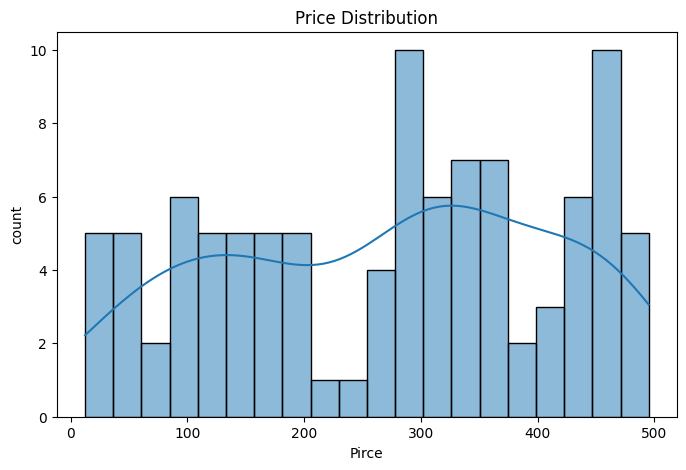

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Price"],bins=20,kde=True)
plt.title("Price Distribution")
plt.xlabel("Pirce")
plt.ylabel("count")
plt.show()

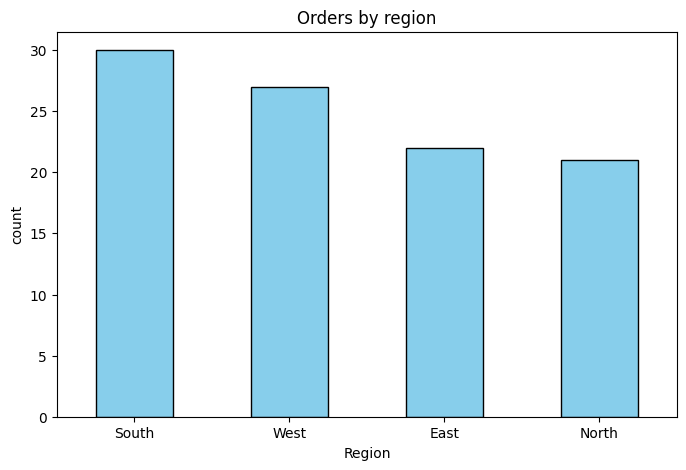

In [7]:
plt.figure(figsize=(8,5))
df_clean["Region"].value_counts().plot(kind="bar" ,color="skyblue",edgecolor="black")
plt.title("Orders by region")
plt.xlabel("Region")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

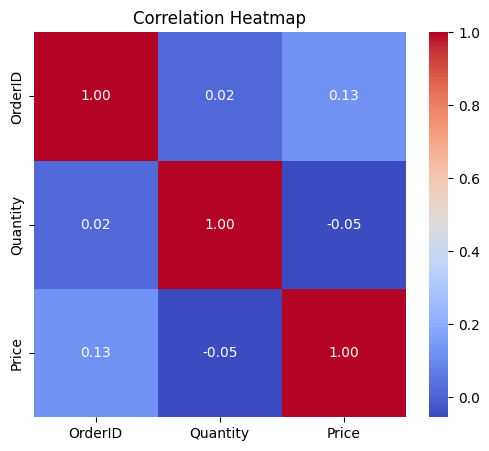

In [8]:
plt.figure(figsize=(6,5))
numeric_df = df_clean.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation,annot =True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# TESTING_MODE =True
# def generate_ai_summary(df , testing_mode=True):
#     stats_text=f"""
# Dataset shape :{df.shape[0]} rows,{df.shape[1]}columns
# columns:{list(df.columns)}
# Numeric Summary:
# {df.describe().to_string()}
#     """
#     if testing_mode:
#         print("ya stats ko jayenge ")
#         print(stats_text)
#         return "mock summary"" ya jaga ai kay response ki hai  "
#     #real api call yaha baad may
#     return None 
# summary = generate_ai_summary(df_clean,testing_mode=TESTING_MODE)
# print(summary)

In [10]:
import os 
from dotenv import load_dotenv
from openai import OpenAI
load_dotenv()
TESTING_MODE=True
def generate_ai_summary(df,testing_mode=True):
    stats_text = f"""
DATASET Shape: {df.shape[0]} rows , {df.shape[1]} columns
Columns List: {list(df.columns)}
Numeric_summary:
{df.describe().to_string()}
Region Distribution:
{df["Region"].value_counts().to_string()}
"""

    if testing_mode:
        print("These stats will be sent to AI ")
        print(stats_text)
        return "Mock summary:Real AI respnose will appear here."



    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    # print( "here is some",client)

    
    response = client.chat.completions.create(
        model ="gpt-4o-mini",
        max_tokens=500,
        messages=[
            {
            "role":"user",
            "content":f"You are a data analyst.Based on the Following statistics, give a Business owner 4-5 clear , plain-Enlglish bullet-point insights (no technical):\n\n{stats_text} "  
            }
        ]
    )
    return response.choices[0].message.content

summary =generate_ai_summary(df_clean,testing_mode=TESTING_MODE)
print(summary)
    

These stats will be sent to AI 

DATASET Shape: 100 rows , 5 columns
Columns List: ['OrderID', 'Product', 'Quantity', 'Price', 'Region']
Numeric_summary:
          OrderID    Quantity       Price
count  100.000000  100.000000  100.000000
mean    50.500000    8.720000  270.147800
std     29.011492    5.486586  142.194606
min      1.000000    1.000000   12.480000
25%     25.750000    4.000000  145.672500
50%     50.500000    8.000000  288.900000
75%     75.250000   13.000000  379.870000
max    100.000000   19.000000  495.130000
Region Distribution:
Region
South    30
West     27
East     22
North    21

Mock summary:Real AI respnose will appear here.


In [16]:
def export_to_excel(df_clean,summary,filename="report.xlsx"):
    with pd.ExcelWriter(filename,engine='openpyxl')as writer:
        df_clean.to_excel(writer,sheet_name="Cleaned_Data",index=False)

        summary_df= pd.DataFrame({"AI Summary":[summary]})
        summary_df.to_excel(writer,sheet_name="AI_Summary",index=False)


        #chaning excel sheet format
        worksheet =writer.sheets["AI_Summary"]
        worksheet.column_dimensions["A"].width =100
        from openpyxl.styles import Alignment 
        worksheet["A2"].alignment = Alignment(wrap_text =True,vertical="top")
        worksheet.row_dimensions[2].height =200
        
    print(f"excel file saved as {filename}")    

export_to_excel(df_clean,summary)

excel file saved as report.xlsx
